# Analyse results from Pypsa-Earth
This notebook reads the latest optimization described in the config.yaml file and makes plots and summaries of the results.

Here, I would like to analyse an electricity-only model run for Algieria, using voronoi clustering with eight clusters.

Sources: 
- Plot capacity - map view: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/viz/regional_transm_system_viz.ipynb
- Analyse energy potential: https://github.com/pypsa-meets-earth/documentation/blob/main/notebooks/build_renewable_profiles.ipynb
- Analyse energy generation: https://pypsa.readthedocs.io/en/latest/examples/statistics.html

Some files are needed:
* PyPSA network file (e.g. "elec.nc" contains a lot of details and looks perfect)
* a country shape file (may be found in "resources/shapes/country_shapes.geojson")
* a renewable profile file (may be found in "resources/renewable_profiles/....nc)

## Import packages

In [1]:
import yaml
import pypsa
import warnings
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np
import pandas as pd
from pathlib import Path
import seaborn as sns
from datetime import datetime
from cartopy import crs as ccrs
from pypsa.plot import add_legend_circles, add_legend_lines, add_legend_patches
import os
import xarray as xr
import cartopy

In [2]:
# change current directory to parent folder
import os
import sys

if not os.path.isdir("pypsa-earth"):
    os.chdir("../..")
sys.path.append(os.getcwd()+"/pypsa-earth/scripts")

## Path settings
This section reads the config parameters from your config.yaml file and automatically reads the output of the optimization with those settings

In [3]:
PARENT = os.path.realpath("pypsa-earth/") + "/"
config = yaml.safe_load(open(PARENT + "own-configs/config-2030-DZ-voronoi-onlyelec-8-24H.yaml"))

# Read config.yaml settings:
name = config["run"]["name"]
simpl = config["scenario"]["simpl"]
clusters = config["scenario"]["clusters"]
ll = config["scenario"]["ll"]
opts = config["scenario"]["opts"]

# Ensure elements are strings and properly joined
simpl_str = "_".join(map(str, simpl))
clusters_str = "_".join(map(str, clusters))
ll_str = "_".join(map(str, ll))
opts_str = "_".join(map(str, opts))

nc_file_name = f"elec_s{simpl_str}_{clusters_str}_ec_l{ll_str}_{opts_str}.nc"
scenario_name = name 
scenario_subpath = scenario_name + "/" if scenario_name else ""

# Network file
results_path = PARENT + f"results/{scenario_subpath}networks/{nc_file_name}"
network_path = PARENT + f"networks/{scenario_subpath}elec.nc"
# Country shape file
regions_onshore_path = PARENT + f"resources/{scenario_subpath}shapes/country_shapes.geojson"
# Renewable profile file
solar_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_solar.nc"
onwind_path = PARENT + f"resources/{scenario_subpath}renewable_profiles/profile_onwind.nc"

## Energy system analysis setup - power and energy generation

In [4]:
warnings.simplefilter(action='ignore', category=FutureWarning)
n = pypsa.Network(results_path)
regions_onshore = gpd.read_file(regions_onshore_path)
country_coordinates = regions_onshore.total_bounds[[0, 2, 1, 3]]
warnings.simplefilter(action='default', category=FutureWarning)

INFO:pypsa.io:Imported network elec_s_8_ec_lcopt_Co2L-24H.nc has buses, carriers, generators, global_constraints, lines, links, loads, storage_units, stores


## Data import check

Plot of the region of interest

Text(0.5, 1.0, 'DZ')

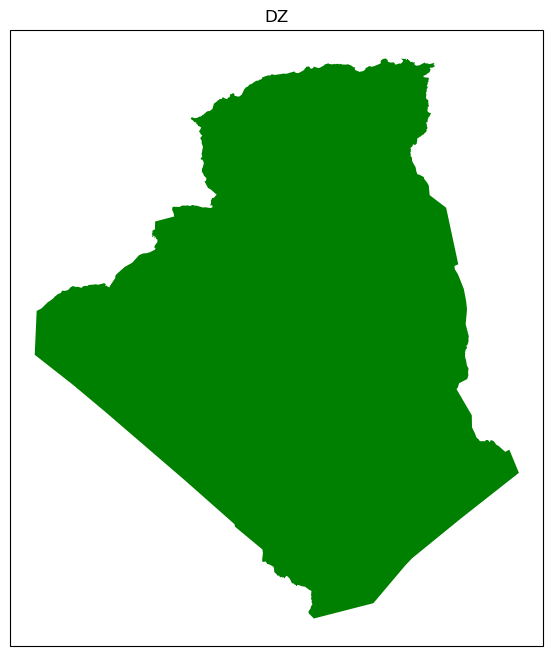

In [5]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
with plt.rc_context({"patch.linewidth": 0.}):
    regions_onshore.plot(
    ax=ax,
    facecolor="green",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
    )
ax.set_title(", ".join(regions_onshore.name.values))

List number of components by type

In [6]:
for c in n.iterate_components(list(n.components.keys())[2:]):
    print("Component '{}' has {} entries".format(c.name,len(c.df)))

Component 'Bus' has 93 entries
Component 'Carrier' has 18 entries
Component 'GlobalConstraint' has 1 entries
Component 'Line' has 24 entries
Component 'LineType' has 34 entries
Component 'TransformerType' has 14 entries
Component 'Link' has 124 entries
Component 'Load' has 31 entries
Component 'Generator' has 177 entries
Component 'StorageUnit' has 1 entries
Component 'Store' has 62 entries


List the snapshots of the PyPSA network

In [7]:
print(n.snapshots)
print(f"Time steps: " + str(len(n.snapshots)))

DatetimeIndex(['2013-01-01', '2013-01-02', '2013-01-03', '2013-01-04',
               '2013-01-05', '2013-01-06', '2013-01-07', '2013-01-08',
               '2013-01-09', '2013-01-10',
               ...
               '2013-12-22', '2013-12-23', '2013-12-24', '2013-12-25',
               '2013-12-26', '2013-12-27', '2013-12-28', '2013-12-29',
               '2013-12-30', '2013-12-31'],
              dtype='datetime64[ns]', name='snapshot', length=365, freq=None)
Time steps: 365


## Analyse energy system

Analyse the current capacity of the energy system - map view

In [32]:
buses

bus    carrier   
DZ0 0  CCGT          3125.500000
       offwind-ac       0.000092
       offwind-dc       0.000109
       oil            463.167748
       onwind           0.000710
                        ...     
DZ8 0  onwind           0.000185
       solar          244.831366
DZ9 0  onwind           0.001506
       solar          564.080398
DZ0 0  hydro          100.000000
Name: p_nom_opt, Length: 85, dtype: float64

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


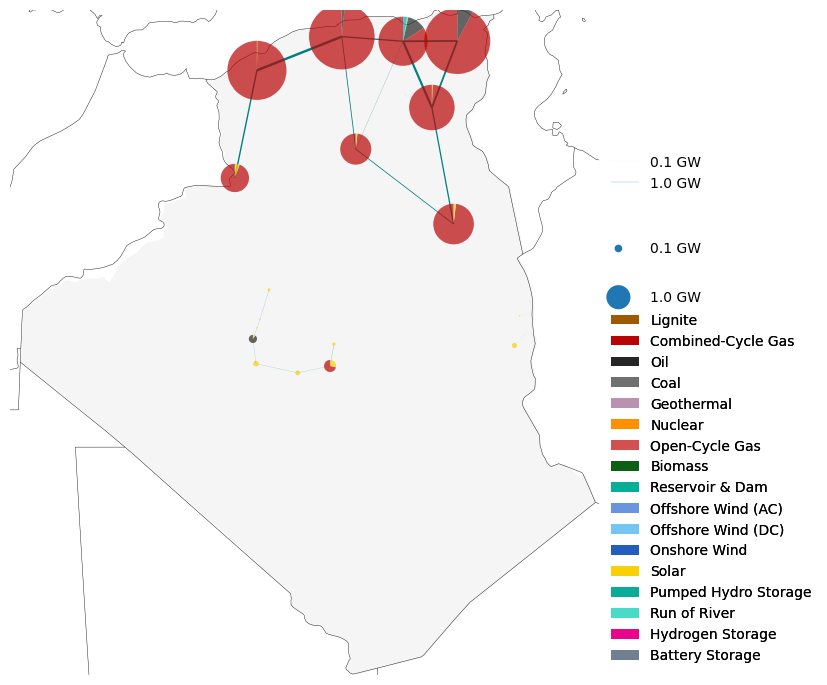

In [8]:
# Scale settings
bus_scale = 6e3 
line_scale = 6e3

# Legend settings
bus_sizes = [100, 1000]  # in MW
line_sizes = [100, 1000]  # in MW

n.carriers.drop("Load", inplace=True)
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Analyse the current generation capacity of the energy system - pie chart view

Text(0.5, 1.0, 'Generator Capacity by Carrier')

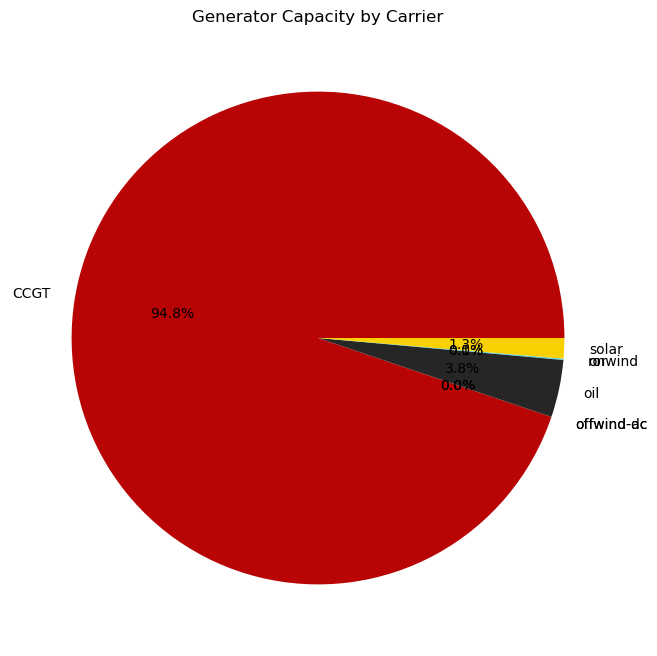

In [9]:
generator_capacity_by_carrier = (
    n.generators[n.generators.carrier != "load"]
    .groupby(["carrier"])
    .p_nom.sum()
)
plt.figure(figsize=(8, 8))
plt.pie(
    generator_capacity_by_carrier,
    labels=generator_capacity_by_carrier.index,
    autopct='%1.1f%%',
    colors=n.carriers[
            n.carriers.index.isin(generator_capacity_by_carrier.index)
        ].color.reindex(generator_capacity_by_carrier.index)
)
plt.title("Generator Capacity by Carrier")

Analyse the current gernation capacity of the energy system - tabular view

In [10]:
generator_capacity_by_carrier/1e3 # in GW

carrier
CCGT          29.635056
offwind-ac     0.000000
offwind-dc     0.000000
oil            1.176446
onwind         0.007590
ror            0.021378
solar          0.416982
Name: p_nom, dtype: float64

Analyse the future capacity of the energy system - map view

/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


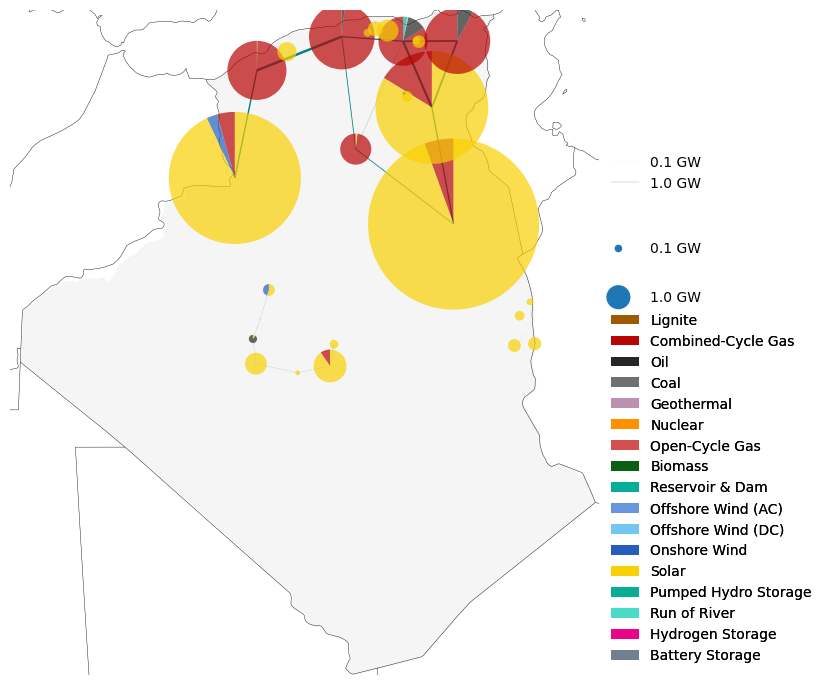

In [11]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"projection": ccrs.EqualEarth(n.buses.x.mean())})
gen = n.generators[n.generators.carrier != "load"].groupby(["bus", "carrier"]).p_nom_opt.sum()
sto = n.storage_units.groupby(["bus", "carrier"]).p_nom_opt.sum()
buses = pd.concat([gen, sto])

with plt.rc_context({"patch.linewidth": 0.}):
    n.plot(
        bus_sizes=buses / bus_scale,
        bus_alpha=0.7,
        line_widths=n.lines.s_nom_opt / line_scale,
        link_widths=n.links.p_nom_opt / line_scale,
        line_colors="teal",
        ax=ax,
        margin=0.2,
        color_geomap=None,
    )
regions_onshore.plot(
    ax=ax,
    facecolor="whitesmoke",
    edgecolor="white",
    aspect="equal",
    transform=ccrs.PlateCarree(),
    linewidth=0,
)
ax.set_extent(regions_onshore.total_bounds[[0, 2, 1, 3]])
legend_kwargs = {"loc": "upper left", "frameon": False}
legend_circles_dict = {"bbox_to_anchor": (1, 0.67), "labelspacing": 2.5, **legend_kwargs}

add_legend_circles(
    ax,
    [s / bus_scale for s in bus_sizes],
    [f"{s / 1000} GW" for s in bus_sizes],
    legend_kw=legend_circles_dict,    
)
add_legend_lines(
    ax,
    [s / line_scale for s in line_sizes],
    [f"{s / 1000} GW" for s in line_sizes],
    legend_kw={"bbox_to_anchor": (1, 0.8), **legend_kwargs},
)
add_legend_patches(
    ax,
    n.carriers.color,
    n.carriers.nice_name,
    legend_kw={"bbox_to_anchor": (1, 0), **legend_kwargs, "loc":"lower left"},
)
fig.tight_layout()

Analys the future generation capacity expansion of the energy system - bar chart

<AxesSubplot:title={'center':'Generator capacity expansion in GW'}, xlabel='carrier'>

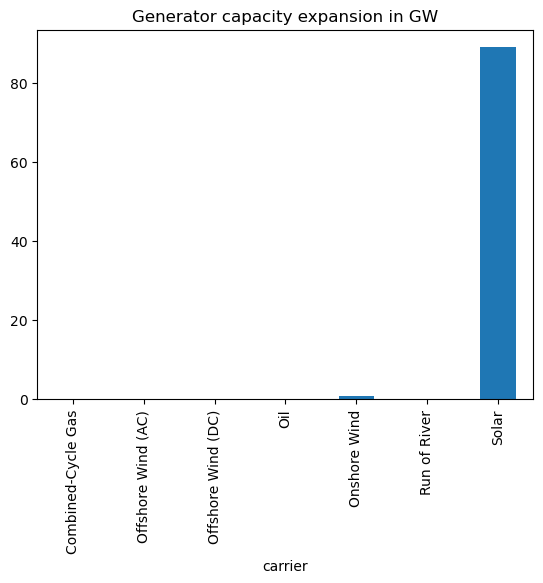

In [12]:
optimal_capacity = n.statistics.optimal_capacity(comps=["Generator"]).droplevel(0).div(1e3)
installed_capacity = n.statistics.installed_capacity(comps=["Generator"]).droplevel(0).div(1e3)
generation_capacity_expansion = optimal_capacity - installed_capacity
generation_capacity_expansion.drop(["load"], inplace=True)
generation_capacity_expansion.plot.bar(title="Generator capacity expansion in GW")

Plot the future generation capacity expansion of the energy system - tabular chart

In [13]:
generation_capacity_expansion # In GW

carrier
Combined-Cycle Gas     0.000000
Offshore Wind (AC)          NaN
Offshore Wind (DC)          NaN
Oil                    0.000000
Onshore Wind           0.821498
Run of River           0.000000
Solar                 89.100500
dtype: float64

Analyse the future energy generation of the energy system - bar chart view

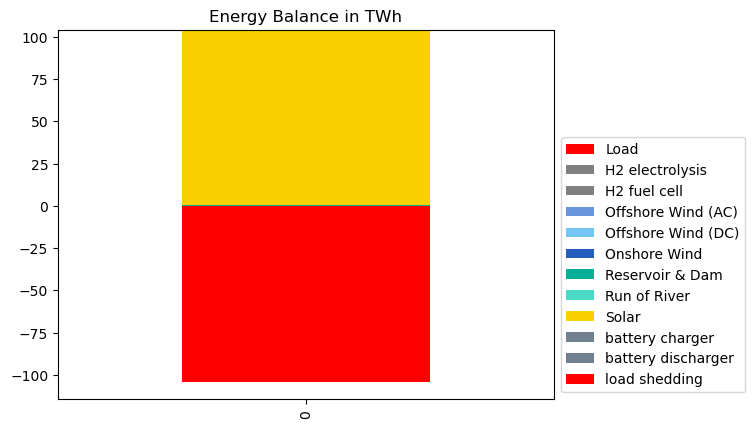

In [14]:
colors = {key.lower(): value.lower() for key, value in config["plotting"]["tech_colors"].items()}
nice_names = {value.lower(): key for key, value in config["plotting"]["nice_names"].items()}

rename_cols = {
    '-': 'Load',
    'load': 'load shedding',
}

energy_balance = (
    n.statistics.energy_balance()
    .loc[:, :, "AC"]
    .groupby("carrier")
    .sum()
    .div(1e6)
    .to_frame()
    .T
    .rename(columns=rename_cols)
)

# color-matching
color_list = []
for col in energy_balance.columns:
    original_name = col.lower()
    key_name = nice_names.get(original_name, original_name)
    color = colors.get(key_name.lower(), 'gray')
    color_list.append(color)


fig, ax = plt.subplots()
energy_balance.plot.bar(stacked=True, ax=ax, title="Energy Balance in TWh", color=color_list)
handles, labels = ax.get_legend_handles_labels()
nice_labels = [config["plotting"]["nice_names"].get(label, label) for label in energy_balance.columns]
ax.legend(handles, nice_labels, bbox_to_anchor=(1, 0), loc="lower left", title=None, ncol=1)

plt.show()

Analyse the future energy generation of the energy system - tabular view

In [15]:
n.statistics.energy_balance()/1e6 # In TWh

component    carrier             bus_carrier
StorageUnit  Reservoir & Dam     AC             1.616980e-01
Link         H2 electrolysis     AC            -4.128458e-02
             H2 fuel cell        H2            -2.566662e-02
             battery charger     AC            -3.397501e-02
             battery discharger  battery       -3.261601e-02
             H2 electrolysis     H2             2.566662e-02
             H2 fuel cell        AC             1.283331e-02
             battery charger     battery        3.261601e-02
             battery discharger  AC             3.131137e-02
Load         -                   AC            -1.040156e+02
Generator    Offshore Wind (AC)  AC             4.465211e-07
             Offshore Wind (DC)  AC             7.847302e-07
             Onshore Wind        AC             4.529422e-02
             Run of River        AC             8.792595e-02
             Solar               AC             1.037518e+02
             load                AC     

## Analyse pv and wind potential - map view

In [16]:
solar = xr.open_dataset(solar_path)
wind = xr.open_dataset(onwind_path)

def plot_voronoi(n, carrier, voronoi, cmap, projection, title=None, filename=None):
    g = n.generators.loc[n.generators.carrier == carrier]
    br = gpd.read_file(f"{PARENT}resources/{scenario_name}/bus_regions/regions_{voronoi}.geojson").set_index("name")
    br_area = br.to_crs("ESRI:54009")
    br_area = br_area.geometry.area * 1e-6
    br["p_nom_max"] = g.groupby("bus").sum().p_nom_max / br_area

    fig, ax = plt.subplots(figsize=(8, 4), subplot_kw={"projection": projection})
    plt.rcParams.update({"font.size": 10})
    br.plot(
        ax=ax,
        column="p_nom_max",
        transform=ccrs.PlateCarree(),
        linewidth=0.25,
        edgecolor="k",
        cmap=cmap,
        vmin=0,
        vmax=br["p_nom_max"].max(),
        legend=True,
        legend_kwds={"label": r"potential density"},
    )
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS.with_scale("110m"))
    ax.set_extent(country_coordinates, crs=ccrs.PlateCarree()) 
    
    if title is not None:
        plt.title(title)

Plot wind energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


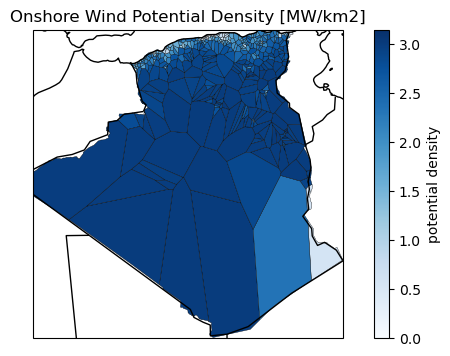

In [17]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "onwind",
    "onshore",
    "Blues",
    ccrs.PlateCarree(),
    title="Onshore Wind Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

Plot pv energy potential

INFO:pypsa.io:Imported network elec.nc has buses, carriers, generators, lines, loads, storage_units, transformers


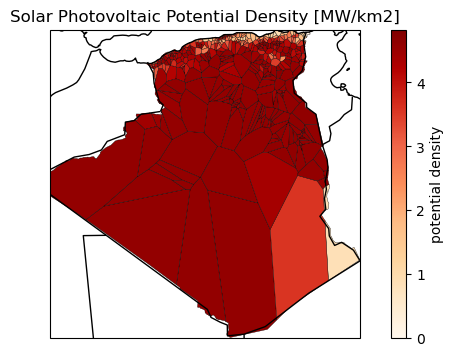

In [18]:
warnings.simplefilter(action='ignore', category=FutureWarning)
plot_voronoi(
    pypsa.Network(network_path),
    "solar",
    "onshore",
    "OrRd",
    ccrs.PlateCarree(),
    title="Solar Photovoltaic Potential Density [MW/km2]",
)
warnings.simplefilter(action='default', category=FutureWarning)

## Additional analysis: buses

In [19]:
n.buses.loc[n.buses.carrier == "AC"]

,v_nom,tag_substation,tag_area,lon,lat,country,x,y,control,generator,carrier,type,unit,v_mag_pu_set,v_mag_pu_min,v_mag_pu_max,sub_network
Bus,,,,,,,,,,,,,,,,,
DZ0 0,380.0,transmission,0.0,5.161206,36.182026,DZ,5.161206,36.182026,Slack,DZ0 0 CCGT,AC,,,1.0,0.0,inf,
DZ0 1,380.0,transmission,0.0,-0.321651,35.354134,DZ,-0.321651,35.354134,PQ,,AC,,,1.0,0.0,inf,
DZ0 2,380.0,transmission,0.0,6.997987,31.057200,DZ,6.997987,31.057200,PQ,,AC,,,1.0,0.0,inf,
DZ0 3,380.0,transmission,0.0,-1.062273,32.334009,DZ,-1.062273,32.334009,PQ,,AC,,,1.0,0.0,inf,
DZ0 4,380.0,transmission,0.0,2.852796,36.313776,DZ,2.852796,36.313776,PQ,,AC,,,1.0,0.0,inf,
DZ0 5,380.0,transmission,0.0,6.230026,34.305126,DZ,6.230026,34.305126,PQ,,AC,,,1.0,0.0,inf,
DZ0 6,380.0,transmission,0.0,3.397168,33.138418,DZ,3.397168,33.138418,PQ,,AC,,,1.0,0.0,inf,
DZ0 7,380.0,transmission,0.0,7.202533,36.190064,DZ,7.202533,36.190064,PQ,,AC,,,1.0,0.0,inf,
DZ1 0,380.0,transmission,0.0,2.499700,27.179700,DZ,2.499700,27.179700,Slack,DZ1 0 CCGT,AC,,,1.0,0.0,inf,


/home/marco-s/miniconda3/envs/pypsa-earth-2/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


(<matplotlib.collections.PatchCollection at 0x7ffa7dc530a0>,
 <matplotlib.collections.LineCollection at 0x7ffa7dcb81f0>)

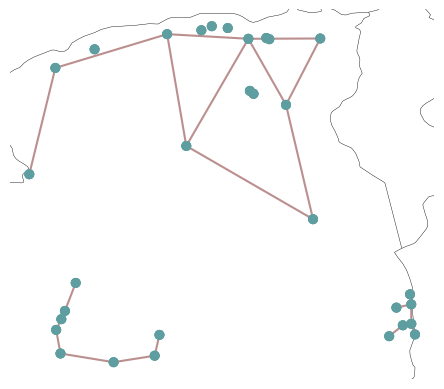

In [20]:
n.plot()

## Additional analysis: Links

In [ ]:
n.links_t.p1

Link,DZ0 0 H2 Electrolysis,DZ0 1 H2 Electrolysis,DZ0 2 H2 Electrolysis,DZ0 3 H2 Electrolysis,DZ0 4 H2 Electrolysis,DZ0 5 H2 Electrolysis,DZ0 6 H2 Electrolysis,DZ0 7 H2 Electrolysis,DZ1 0 H2 Electrolysis,DZ1 1 H2 Electrolysis,...,DZ4 3 battery discharger,DZ4 4 battery discharger,DZ4 5 battery discharger,DZ4 6 battery discharger,DZ5 0 battery discharger,DZ6 0 battery discharger,DZ7 0 battery discharger,DZ7 1 battery discharger,DZ8 0 battery discharger,DZ9 0 battery discharger
snapshot,,,,,,,,,,,,,,,,,,,,,
2013-01-01,-1.061586e-04,-1.056717e-04,-1.087755e-04,-0.000064,-1.062080e-04,-1.078789e-04,-1.072246e-04,-1.061715e-04,-0.000039,-0.000039,...,-0.000477,-0.000476,-0.000476,-0.000476,-0.010125,-0.009010,-0.008546,-0.008675,-0.008633,-14.326733
2013-01-02,-1.042616e-04,-1.046478e-04,-1.078333e-04,-0.000063,-1.053508e-04,-1.055584e-04,-1.055374e-04,-1.050536e-04,-0.000041,-0.000041,...,-0.000476,-0.000475,-0.000475,-0.000475,-4.917586,-0.006677,-0.236832,-0.405450,-2.201864,-0.011446
2013-01-03,-1.016847e-04,-1.023139e-04,-1.044498e-04,-0.000061,-1.020648e-04,-1.032900e-04,-1.027414e-04,-1.018850e-04,-0.000043,-0.000043,...,-0.000484,-0.000483,-0.000483,-0.000484,-8.307191,-1.619415,-0.010277,-0.010408,-1.687682,-0.011878
2013-01-04,-1.069586e-04,-1.038333e-04,-1.077537e-04,-0.000065,-1.046396e-04,-1.077599e-04,-1.061097e-04,-1.045739e-04,-0.000044,-0.000044,...,-0.000493,-0.000492,-0.000492,-0.000492,-1.303553,-0.009139,-0.008194,-0.008298,-2.135488,-0.011486
2013-01-05,-1.086230e-04,-1.069724e-04,-1.094362e-04,-0.000065,-1.068709e-04,-1.094282e-04,-1.080436e-04,-1.074110e-04,-0.000044,-0.000043,...,-0.000466,-0.000465,-0.000466,-0.000466,-0.010816,-0.008887,-0.008308,-0.008411,-0.009073,-0.011579
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2013-12-27,-1.274353e-04,-1.267328e-04,-1.280812e-04,-0.000075,-1.266108e-04,-1.299168e-04,-1.268439e-04,-1.268816e-04,-0.000041,-0.000041,...,-0.000463,-0.000462,-0.000462,-0.000463,-0.000047,-0.008951,-0.008618,-0.008801,-6.024992,-5.197463
2013-12-28,-1.268549e-04,-1.260774e-04,-1.272382e-04,-0.000075,-1.258900e-04,-1.293841e-04,-1.260724e-04,-1.259986e-04,-0.000037,-0.000036,...,-0.000454,-0.000454,-0.000454,-0.000455,-0.000052,-0.008766,-0.008457,-0.008645,-0.000007,-0.000015
2013-12-29,-2.297986e-06,-2.839159e-06,-3.588494e-05,-0.000003,-2.939877e-06,-2.546995e-06,-5.703788e-06,-2.254974e-06,-0.000042,-0.000042,...,-0.000486,-0.000486,-0.000486,-0.000486,-18.009300,-4.949632,-1.499697,-1.517215,-4.043314,-23.539973


## Additional analysis: Lines

In [42]:
n.lines

,num_parallel,v_nom,bus0,bus1,length,dc,geometry,bounds,carrier,type,...,build_year,lifetime,terrain_factor,v_ang_min,v_ang_max,sub_network,x_pu,r_pu,g_pu,b_pu
Line,,,,,,,,,,,,,,,,,,,,,
0,3.197368,380.0,DZ0 0,DZ0 4,259.399185,False,"MULTILINESTRING ((5.3175 35.8456, 5.3161515 35...",MULTIPOINT ((3.5749251999999996 36.25212579999...,AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
1,5.488158,380.0,DZ0 0,DZ0 5,287.705119,False,"MULTILINESTRING ((4.4821 35.705, 4.4821094 35....","MULTIPOINT ((4.4821 35.705), (4.4821094 35.706...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
10,0.289474,380.0,DZ1 0,DZ1 3,146.652917,False,"MULTILINESTRING ((1.3329 26.995, 1.3334163 26....","MULTIPOINT ((1.3329 26.995), (1.3334163 26.995...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
11,0.434211,380.0,DZ1 0,DZ1 4,83.860949,False,MULTILINESTRING ((2.499768199999999 27.1794799...,"MULTIPOINT ((2.4997 27.1797), (2.4997682 27.17...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
12,0.289474,380.0,DZ1 1,DZ1 3,189.859083,False,"MULTILINESTRING ((-0.1765 27.2419, -0.17676290...","MULTIPOINT ((-0.1765 27.2419), (1.332349699999...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
13,0.289474,380.0,DZ1 1,DZ1 5,94.509333,False,"MULTILINESTRING ((-0.2992 27.9131, -0.29877979...","MULTIPOINT ((-0.2992 27.9131), (-0.17691180000...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
14,0.289474,380.0,DZ1 2,DZ1 7,116.729926,False,"MULTILINESTRING ((-0.0501 28.4519, -0.050013 2...","MULTIPOINT ((-0.0501 28.4519), (-0.050013 28.4...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
15,0.289474,380.0,DZ1 5,DZ1 6,45.958194,False,"MULTILINESTRING ((-0.2992 27.9131, -0.2997719 ...","MULTIPOINT ((-0.2997719 27.93212840000038), (-...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
16,0.289474,380.0,DZ1 6,DZ1 7,34.925058,False,"MULTILINESTRING ((-0.1542 28.2696, -0.1547684 ...","MULTIPOINT ((-0.1542 28.2696), (-0.05023240000...",AC,Al/St 240/40 4-bundle 380.0,...,0,inf,1.0,-inf,inf,,0.0,0.0,0.0,0.0
